# Graph Neural Networks (GNNs)

This notebook explores the fundamental concepts of Graph Neural Networks —
a powerful class of models designed for data with relational structure
(social networks, molecules, knowledge graphs, etc.).

**Prerequisites:**
```bash
pip install numpy matplotlib scikit-learn
```

📺 **Video Lecture:** [https://youtu.be/2wre5n0cCf8](https://youtu.be/2wre5n0cCf8)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
np.random.seed(42)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## 1. Graph Representation

A graph $G = (V, E)$ consists of:
- **Nodes (vertices)** $V$: entities (e.g., users, atoms)
- **Edges** $E$: relationships between entities

We represent graphs with:
- **Adjacency matrix** $A$: $A_{ij} = 1$ if edge exists between node $i$ and $j$
- **Node feature matrix** $X$: each row is a node's feature vector

In [3]:
# Create a small social network graph
# Nodes: 6 people in 2 communities
node_names = ['Alice', 'Bob', 'Carol', 'Dave', 'Eve', 'Frank']
n_nodes = len(node_names)

# Adjacency matrix (undirected graph)
A = np.array([
    [0, 1, 1, 0, 0, 0],  # Alice connected to Bob, Carol
    [1, 0, 1, 1, 0, 0],  # Bob connected to Alice, Carol, Dave
    [1, 1, 0, 0, 0, 0],  # Carol connected to Alice, Bob
    [0, 1, 0, 0, 1, 1],  # Dave connected to Bob, Eve, Frank
    [0, 0, 0, 1, 0, 1],  # Eve connected to Dave, Frank
    [0, 0, 0, 1, 1, 0],  # Frank connected to Dave, Eve
], dtype=float)

# Node features: [age_normalized, income_normalized, activity_level]
X = np.array([
    [0.3, 0.5, 0.8],  # Alice: young, medium income, active
    [0.4, 0.6, 0.7],  # Bob
    [0.3, 0.4, 0.9],  # Carol
    [0.7, 0.8, 0.4],  # Dave: older, high income, less active
    [0.8, 0.9, 0.3],  # Eve
    [0.6, 0.7, 0.5],  # Frank
])

print(f'Number of nodes: {n_nodes}')
print(f'Number of edges: {int(A.sum() / 2)}')
print(f'Node feature dimensionality: {X.shape[1]}')
print(f'\nAdjacency Matrix:')
print(A.astype(int))

Number of nodes: 6
Number of edges: 7
Node feature dimensionality: 3

Adjacency Matrix:
[[0 1 1 0 0 0]
 [1 0 1 1 0 0]
 [1 1 0 0 0 0]
 [0 1 0 0 1 1]
 [0 0 0 1 0 1]
 [0 0 0 1 1 0]]


## 2. Visualizing the Graph

Let's visualize our social network to see the two communities.

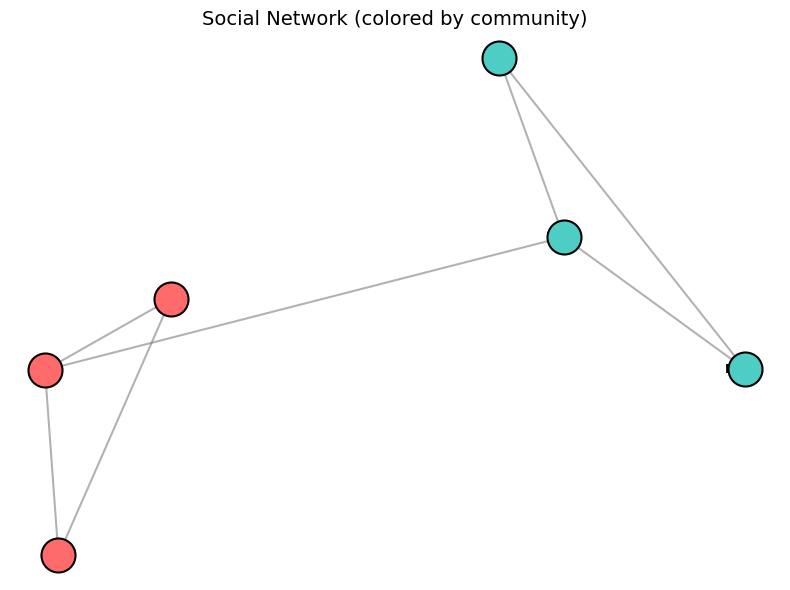

In [4]:
def draw_graph(A, node_names, node_colors=None, title='Graph'):
    """Draw a graph using a simple force-directed layout."""
    n = len(A)
    # Simple spring layout
    np.random.seed(1)
    pos = np.random.randn(n, 2) * 0.5
    
    # Iterate spring forces
    for _ in range(100):
        forces = np.zeros_like(pos)
        for i in range(n):
            for j in range(n):
                diff = pos[i] - pos[j]
                dist = np.linalg.norm(diff) + 1e-6
                if A[i, j] > 0:  # attraction for connected nodes
                    forces[i] -= diff * 0.1
                # repulsion for all nodes
                forces[i] += diff / (dist ** 2) * 0.05
        pos += forces * 0.1
    
    fig, ax = plt.subplots(figsize=(8, 6))
    # Draw edges
    for i in range(n):
        for j in range(i+1, n):
            if A[i, j] > 0:
                ax.plot([pos[i,0], pos[j,0]], [pos[i,1], pos[j,1]],
                       'gray', linewidth=1.5, alpha=0.6)
    # Draw nodes
    colors = node_colors if node_colors is not None else ['#4ECDC4'] * n
    for i in range(n):
        ax.scatter(pos[i,0], pos[i,1], s=600, c=colors[i], zorder=5,
                  edgecolors='black', linewidth=1.5)
        ax.text(pos[i,0], pos[i,1], node_names[i], ha='center', va='center',
               fontsize=9, fontweight='bold')
    ax.set_title(title, fontsize=14)
    ax.axis('off')
    plt.tight_layout()
    return fig, ax

# Color by community
colors = ['#FF6B6B', '#FF6B6B', '#FF6B6B', '#4ECDC4', '#4ECDC4', '#4ECDC4']
draw_graph(A, node_names, colors, 'Social Network (colored by community)')
plt.show()

## 3. Message Passing — The Core of GNNs

GNNs learn node representations by **aggregating information from neighbors**.
Each layer performs:

$$h_v^{(l+1)} = \sigma\left(W \cdot \text{AGGREGATE}\left(\{h_u^{(l)} : u \in \mathcal{N}(v)\}\right)\right)$$

This is called **message passing** — each node collects "messages" from its
neighbors to update its own representation.

In [5]:
def message_passing_layer(A, X, W, bias=None, activation='relu'):
    """
    One layer of graph message passing.
    
    Steps:
    1. Aggregate neighbor features: A @ X (sum of neighbor features)
    2. Transform: aggregated @ W (linear projection)
    3. Apply activation function
    
    Parameters:
    -----------
    A : adjacency matrix (n x n)
    X : node features (n x d_in)
    W : weight matrix (d_in x d_out)
    """
    # Add self-loops: each node also aggregates its own features
    A_hat = A + np.eye(len(A))
    
    # Degree normalization (prevents feature magnitudes from growing)
    D = np.diag(A_hat.sum(axis=1))
    D_inv_sqrt = np.diag(1.0 / np.sqrt(A_hat.sum(axis=1)))
    A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt  # symmetric normalization
    
    # Message passing: aggregate + transform
    H = A_norm @ X @ W
    
    if bias is not None:
        H += bias
    
    # Activation
    if activation == 'relu':
        H = np.maximum(0, H)
    elif activation == 'tanh':
        H = np.tanh(H)
    
    return H

# Initialize random weights for a 2-layer GNN
# Layer 1: 3 input features → 4 hidden features
np.random.seed(42)
W1 = np.random.randn(3, 4) * 0.5
# Layer 2: 4 hidden → 2 output (e.g., for 2-class classification)
W2 = np.random.randn(4, 2) * 0.5

# Forward pass
H1 = message_passing_layer(A, X, W1, activation='relu')
H2 = message_passing_layer(A, H1, W2, activation='tanh')

print('Input features X (shape {}):\n{}'.format(X.shape, X))
print(f'\nAfter Layer 1 (shape {H1.shape}):\n{np.round(H1, 3)}')
print(f'\nAfter Layer 2 (shape {H2.shape}) — node embeddings:\n{np.round(H2, 3)}')

Input features X (shape (6, 3)):
[[0.3 0.5 0.8]
 [0.4 0.6 0.7]
 [0.3 0.4 0.9]
 [0.7 0.8 0.4]
 [0.8 0.9 0.3]
 [0.6 0.7 0.5]]

After Layer 1 (shape (6, 4)):
[[0.    0.131 0.298 0.243]
 [0.    0.105 0.449 0.397]
 [0.    0.131 0.298 0.243]
 [0.    0.    0.744 0.711]
 [0.    0.    0.731 0.714]
 [0.    0.    0.731 0.714]]

After Layer 2 (shape (6, 2)) — node embeddings:
[[-0.374 -0.175]
 [-0.474 -0.244]
 [-0.374 -0.175]
 [-0.605 -0.363]
 [-0.582 -0.354]
 [-0.582 -0.354]]


## 4. Aggregation Illustrated

Let's trace exactly what happens to **Alice's** representation in one layer.
Alice is connected to Bob and Carol, so she aggregates their features.

In [6]:
# Manual trace for Alice (node 0)
alice_idx = 0
alice_neighbors = np.where(A[alice_idx] > 0)[0]

print(f"Alice's neighbors: {[node_names[i] for i in alice_neighbors]}")
print(f"\nAlice's own features:     {X[alice_idx]}")
for n_idx in alice_neighbors:
    print(f"{node_names[n_idx]}'s features:       {X[n_idx]}")

# Simple mean aggregation (including self)
all_features = np.vstack([X[alice_idx]] + [X[i] for i in alice_neighbors])
aggregated = all_features.mean(axis=0)
print(f"\nMean-aggregated features: {np.round(aggregated, 3)}")
print(f"Interpretation: Alice's new representation blends her features")
print(f"with Bob's and Carol's — capturing her local neighborhood!")

Alice's neighbors: ['Bob', 'Carol']

Alice's own features:     [0.3 0.5 0.8]
Bob's features:       [0.4 0.6 0.7]
Carol's features:       [0.3 0.4 0.9]

Mean-aggregated features: [0.333 0.5   0.8  ]
Interpretation: Alice's new representation blends her features
with Bob's and Carol's — capturing her local neighborhood!


## 5. GNN Variants

Different GNN architectures use different aggregation strategies:

| Model | Aggregation | Key Idea |
|-------|------------|----------|
| GCN | Mean (normalized) | Simple, effective baseline |
| GraphSAGE | Sample + aggregate | Scalable to large graphs |
| GAT | Attention-weighted | Learn which neighbors matter more |
| GIN | Sum + MLP | Maximally expressive for graph isomorphism |

In [7]:
# Implement GAT-style attention for one node
def attention_aggregate(node_idx, A, X, W_attn):
    """
    Graph Attention: learn how much to attend to each neighbor.
    Attention scores = softmax(a^T [Wh_i || Wh_j])
    """
    neighbors = np.where(A[node_idx] > 0)[0]
    all_nodes = np.concatenate([[node_idx], neighbors])
    
    # Compute attention scores (simplified: dot product attention)
    query = X[node_idx] @ W_attn
    keys = X[all_nodes] @ W_attn
    scores = keys @ query  # dot product
    
    # Softmax
    scores = np.exp(scores - scores.max())
    attn_weights = scores / scores.sum()
    
    # Weighted aggregation
    output = (attn_weights[:, None] * X[all_nodes]).sum(axis=0)
    
    return output, dict(zip([node_names[i] for i in all_nodes], np.round(attn_weights, 3)))

W_attn = np.random.randn(3, 3) * 0.5

for idx in [0, 3]:  # Alice and Dave
    output, weights = attention_aggregate(idx, A, X, W_attn)
    print(f"{node_names[idx]}'s attention weights: {weights}")
    print(f"  Aggregated representation: {np.round(output, 3)}\n")

Alice's attention weights: {'Alice': np.float64(0.338), 'Bob': np.float64(0.324), 'Carol': np.float64(0.338)}
  Aggregated representation: [0.332 0.499 0.801]

Dave's attention weights: {'Dave': np.float64(0.247), 'Bob': np.float64(0.259), 'Eve': np.float64(0.246), 'Frank': np.float64(0.249)}
  Aggregated representation: [0.622 0.748 0.478]



## 6. Node Classification Task

A common GNN task: predict a label for each node using the graph structure.
We'll train a simple 2-layer GNN to classify nodes into communities.

Training complete!
Final loss: 3.3012
Predictions: [0 0 0 0 0 0]
True labels: [0 0 0 1 1 1]
Accuracy: 50%


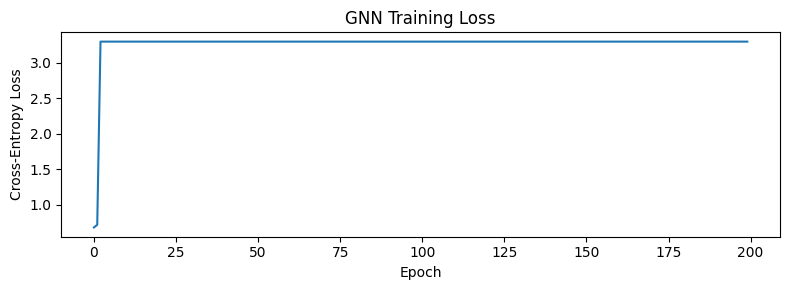

In [8]:
# Ground truth labels (community assignment)
y_true = np.array([0, 0, 0, 1, 1, 1])  # Community A: Alice,Bob,Carol; B: Dave,Eve,Frank

def softmax(x):
    e = np.exp(x - x.max(axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

def cross_entropy_loss(probs, labels):
    n = len(labels)
    return -np.sum(np.log(probs[range(n), labels] + 1e-8)) / n

# Training loop with gradient descent (simplified, finite differences)
np.random.seed(123)
W1 = np.random.randn(3, 4) * 0.3
W2 = np.random.randn(4, 2) * 0.3
lr = 0.01
losses = []

for epoch in range(200):
    # Forward
    H1 = message_passing_layer(A, X, W1, activation='relu')
    logits = message_passing_layer(A, H1, W2, activation=None)
    probs = softmax(logits)
    loss = cross_entropy_loss(probs, y_true)
    losses.append(loss)
    
    # Numerical gradient update (for simplicity — real GNNs use autograd)
    eps = 1e-4
    for W in [W1, W2]:
        for i in range(W.shape[0]):
            for j in range(W.shape[1]):
                W[i,j] += eps
                H1_ = message_passing_layer(A, X, W1, activation='relu')
                logits_ = message_passing_layer(A, H1_, W2, activation=None)
                loss_plus = cross_entropy_loss(softmax(logits_), y_true)
                W[i,j] -= eps
                grad = (loss_plus - loss) / eps
                W[i,j] -= lr * grad

# Final predictions
H1 = message_passing_layer(A, X, W1, activation='relu')
logits = message_passing_layer(A, H1, W2, activation=None)
preds = softmax(logits).argmax(axis=1)

print('Training complete!')
print(f'Final loss: {losses[-1]:.4f}')
print(f'Predictions: {preds}')
print(f'True labels: {y_true}')
print(f'Accuracy: {(preds == y_true).mean()*100:.0f}%')

# Plot loss curve
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses)
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.set_title('GNN Training Loss'); plt.tight_layout(); plt.show()

## 7. Graph-Level Prediction (Graph Pooling)

For graph classification (e.g., is this molecule toxic?),
we need to go from node embeddings to a single graph embedding.

Common pooling strategies:
- **Mean pooling**: average all node embeddings
- **Sum pooling**: sum all node embeddings
- **Hierarchical pooling**: progressively coarsen the graph

In [9]:
# Demonstrate graph pooling
# After GNN layers, we have node embeddings H2
H_final = message_passing_layer(A, X, W1, activation='relu')

# Pooling strategies
mean_pool = H_final.mean(axis=0)
sum_pool = H_final.sum(axis=0)
max_pool = H_final.max(axis=0)

print(f'Node embeddings shape: {H_final.shape}')
print(f'\nGraph embedding (mean pool): {np.round(mean_pool, 3)}')
print(f'Graph embedding (sum pool):  {np.round(sum_pool, 3)}')
print(f'Graph embedding (max pool):  {np.round(max_pool, 3)}')
print(f'\n→ These fixed-size vectors can feed into a classifier for graph-level tasks')

Node embeddings shape: (6, 4)

Graph embedding (mean pool): [0.    0.    0.309 0.465]
Graph embedding (sum pool):  [0.    0.    1.856 2.793]
Graph embedding (max pool):  [0.    0.    0.738 1.047]

→ These fixed-size vectors can feed into a classifier for graph-level tasks


## 8. Receptive Field & Over-Smoothing

Each GNN layer lets information flow one hop further.
With $k$ layers, each node sees its $k$-hop neighborhood.

**Over-smoothing problem**: too many layers → all node representations converge,
losing distinguishing features. This is a key challenge in deep GNNs.

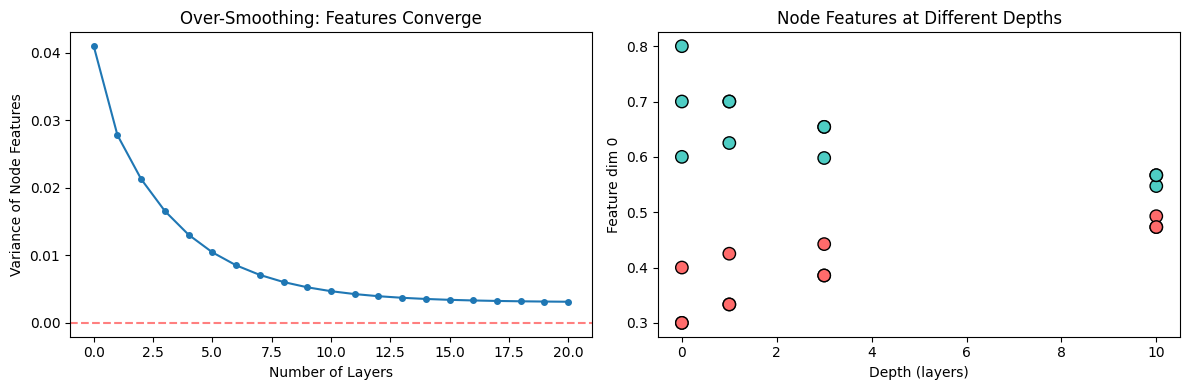

Notice: deeper layers → all node features converge to same value!


In [10]:
# Demonstrate over-smoothing
# Run many message passing layers and watch node features converge
W_identity = np.eye(3) * 0.8  # near-identity to isolate the smoothing effect

H = X.copy()
variances = [np.var(H)]

for layer in range(20):
    A_hat = A + np.eye(n_nodes)
    D_inv = np.diag(1.0 / A_hat.sum(axis=1))
    H = D_inv @ A_hat @ H  # mean aggregation without learned weights
    variances.append(np.var(H))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(variances, 'o-', markersize=4)
ax1.set_xlabel('Number of Layers')
ax1.set_ylabel('Variance of Node Features')
ax1.set_title('Over-Smoothing: Features Converge')
ax1.axhline(y=0, linestyle='--', color='red', alpha=0.5)

# Show node features at different depths
depths = [0, 1, 3, 10]
for i, d in enumerate(depths):
    H = X.copy()
    for _ in range(d):
        A_hat = A + np.eye(n_nodes)
        D_inv = np.diag(1.0 / A_hat.sum(axis=1))
        H = D_inv @ A_hat @ H
    ax2.scatter([d]*n_nodes, H[:, 0], c=colors, s=80, edgecolors='black')

ax2.set_xlabel('Depth (layers)'); ax2.set_ylabel('Feature dim 0')
ax2.set_title('Node Features at Different Depths')
plt.tight_layout(); plt.show()
print('Notice: deeper layers → all node features converge to same value!')

## 9. Interview Takeaways

**Key concepts to remember:**

- **GNNs** learn node representations by aggregating neighbor information (message passing)
- **Adjacency + Features** → the two essential inputs to any GNN
- **GCN** uses normalized mean aggregation; **GAT** uses learned attention weights
- **Tasks**: node classification, link prediction, graph classification
- **Receptive field** grows with depth — $k$ layers = $k$-hop neighborhood
- **Over-smoothing** limits depth; solutions include skip connections, dropout, jumping knowledge
- **Applications**: social networks, drug discovery, fraud detection, recommendation systems
- Popular frameworks: PyG (PyTorch Geometric), DGL (Deep Graph Library)

---

<small><em>© 2026 AI Nirvana · More Info: https://medium.com/@snigam/a-simple-structured-way-to-prepare-for-ai-ml-interviews-68b2e5830195 · Disclaimer: Provided as is. No liability assumed.</em></small>